Compiling model...
'compile' took 0.000371 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [7.37e-01, 1.03e-01, 1.00e+04, 4.01e+02]    [7.37e-01, 1.03e-01, 1.00e+04, 4.01e+02]    []  
1000      [6.64e+00, 2.03e+01, 5.20e+03, 9.80e+00]    [6.64e+00, 2.03e+01, 5.20e+03, 9.80e+00]    []  
2000      [7.19e+00, 1.49e+01, 2.89e+03, 3.44e-01]    [7.19e+00, 1.49e+01, 2.89e+03, 3.44e-01]    []  
3000      [4.84e+00, 8.16e+00, 1.41e+03, 5.24e-02]    [4.84e+00, 8.16e+00, 1.41e+03, 5.24e-02]    []  
4000      [3.12e+00, 4.42e+00, 5.61e+02, 9.87e-05]    [3.12e+00, 4.42e+00, 5.61e+02, 9.87e-05]    []  
5000      [1.28e+00, 1.71e+00, 1.56e+02, 9.25e-04]    [1.28e+00, 1.71e+00, 1.56e+02, 9.25e-04]    []  
6000      [3.55e-01, 4.16e-01, 2.29e+01, 5.27e-04]    [3.55e-01, 4.16e-01, 2.29e+01, 5.27e-04]    []  
7000      [1.06e-01, 1.07e-01, 1.09e+00, 2.22e-04]    [1.06e-01, 1.07e-01, 1.09e+00, 2.22e-04]    []  
8

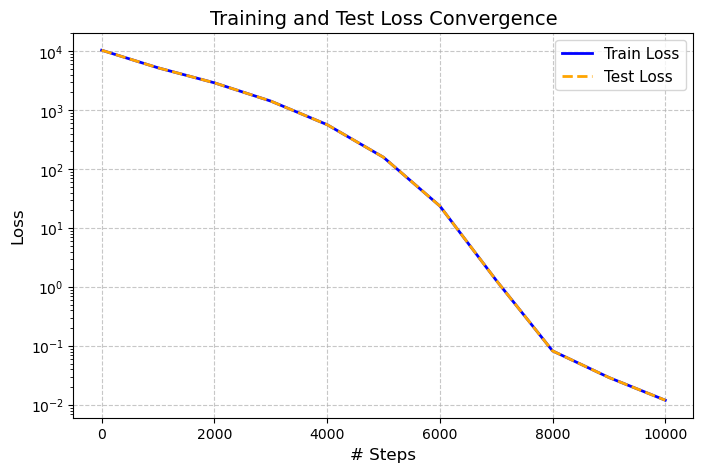

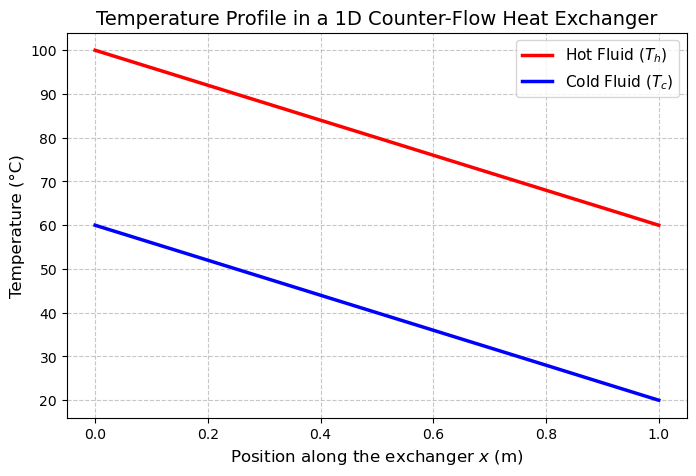

In [2]:
import os
# עוקף את שגיאת ההתנגשות של ספריות Intel MKL/OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# הגדרת ה-Backend של DeepXDE
os.environ["DDE_BACKEND"] = "pytorch" # שנה ל-"tensorflow" אם זה מה שמותקן אצלך
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt  # הוספנו את ספריית הציור

# הגדרת הקבועים של המערכת (לצורך ההדגמה, נניח שהם 1.0)
# אלו מייצגים את k = (U * A) / (m * c_p)
k_h = 1.0
k_c = 1.0

def pde(x, y):
    """
    פונקציה זו מגדירה את משוואות הפיזיקה (ODEs).
    DeepXDE מצפה לקבל את ה"שארית" (Residual) של המשוואה, כלומר המשוואה שווה לאפס.
    """
    # הרשת מוציאה וקטור של שתי טמפרטורות
    T_h = y[:, 0:1] # טמפרטורת הזורם החם
    T_c = y[:, 1:2] # טמפרטורת הזורם הקר

    # נגזרות של הטמפרטורה ביחס למיקום x
    dT_h_dx = dde.grad.jacobian(y, x, i=0)
    dT_c_dx = dde.grad.jacobian(y, x, i=1)

    # משוואות שימור האנרגיה (מבוסס על הדוח שלכם)
    eq_h = dT_h_dx + k_h * (T_h - T_c)
    eq_c = dT_c_dx + k_c * (T_h - T_c)

    return [eq_h, eq_c]

# --- 1. הגדרת הגיאומטריה (1D) ---
geom = dde.geometry.Interval(0, 1)

# --- 2. הגדרת תנאי השפה (Boundary Conditions) ---
# נגדיר זרימה נגדית (Counter-flow): החם נכנס מ-x=0 והקר נכנס מ-x=1
def boundary_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)

def boundary_right(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1)

# טמפרטורת כניסה של הזורם החם: 100 מעלות
bc_h = dde.icbc.DirichletBC(geom, lambda x: 100.0, boundary_left, component=0)
# טמפרטורת כניסה של הזורם הקר: 20 מעלות
bc_c = dde.icbc.DirichletBC(geom, lambda x: 20.0, boundary_right, component=1)

# --- 3. הגדרת הנתונים והרשת ---
# num_domain: מספר הנקודות שבהן נדגום את הפיזיקה לאורך הצינור
data = dde.data.PDE(
    geom, pde, [bc_h, bc_c], num_domain=100, num_boundary=2
)

# ארכיטקטורת הרשת: כניסה 1 (x), שלוש שכבות נסתרות של 20 נוירונים, 2 יציאות (T_h, T_c)
net = dde.nn.FNN([1] + [20] * 3 + [2], "tanh", "Glorot normal")

model = dde.Model(data, net)

# --- 4. אימון המודל ---
model.compile("adam", lr=0.001)
losshistory, train_state = model.train(iterations=10000)

# נכבה את ההדפסה האוטומטית של DeepXDE לחלוטין (isplot=False)
dde.saveplot(losshistory, train_state, issave=False, isplot=False)

# --- 5. הצגה אקדמית ומותאמת אישית של הגרפים ---

# --- גרף 1: התכנסות השגיאה (Loss) ---
# נשלוף את נתוני השגיאה מתוך היסטוריית האימון ונחבר את כל רכיבי הפונקציה
steps = losshistory.steps
loss_train = np.sum(losshistory.loss_train, axis=1)
loss_test = np.sum(losshistory.loss_test, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(steps, loss_train, label='Train Loss', color='blue', linewidth=2)
plt.plot(steps, loss_test, label='Test Loss', color='orange', linestyle='--', linewidth=2)

# הגדרת סקאלה לוגריתמית (חשוב מאוד לגרפי שגיאה)
plt.yscale('log')
plt.title('Training and Test Loss Convergence', fontsize=14)
plt.xlabel('# Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- גרף 2: פרופיל הטמפרטורות ---
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred = model.predict(x_test)
T_h_pred = y_pred[:, 0]
T_c_pred = y_pred[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(x_test, T_h_pred, color='red', linewidth=2.5, label='Hot Fluid ($T_h$)')
plt.plot(x_test, T_c_pred, color='blue', linewidth=2.5, label='Cold Fluid ($T_c$)')

plt.title('Temperature Profile in a 1D Counter-Flow Heat Exchanger', fontsize=14)
plt.xlabel('Position along the exchanger $x$ (m)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()